# Laboratorio 02: Estrategia de trading con análisis técnico

NVDA en velas de 5 minutos. Este notebook solo importa funciones de `src/` y genera tablas y figuras; no contiene la lógica de los indicadores ni del backtest.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import auditar_datos, cargar_datos, separar_train_test
from src.signals import MODOS, PARAMETROS_BASE, calcular_indicadores, generar_senales
from src.backtest import ejecutar_backtest
from src.metrics import resumen_metricas, tablas_retornos
from src.plots import plot_indicadores, plot_operaciones, plot_valor_drawdown

SEED = 42
np.random.seed(SEED)
DIA_EJEMPLO = "2026-03-16"

## 1. Datos

In [2]:
datos = cargar_datos()
datos

,Open,High,Low,Close,Volume
Datetime,,,,,
2026-01-02 09:30:00-05:00,189.8350,191.2200,189.570,191.1200,8196408.0
2026-01-02 09:35:00-05:00,191.1300,191.8600,190.890,190.9984,5019016.0
2026-01-02 09:40:00-05:00,190.9700,191.9110,190.520,191.8000,4149936.0
2026-01-02 09:45:00-05:00,191.7999,192.6400,191.630,192.3600,4594664.0
2026-01-02 09:50:00-05:00,192.3700,192.9299,192.120,192.3100,3658528.0
...,...,...,...,...,...
2026-09-25 15:35:00-04:00,223.9499,224.2650,223.825,224.2250,714895.0
2026-09-25 15:40:00-04:00,224.2300,224.3100,224.030,224.1800,644838.0
2026-09-25 15:45:00-04:00,224.1900,224.7300,224.190,224.7150,1216695.0


In [3]:
pd.Series(auditar_datos(datos)).to_frame("valor")

,valor
velas,14352
inicio,2026-01-02 09:30:00-05:00
fin,2026-09-25 15:55:00-04:00
dias,184
duplicados,0
nulos,0
ohlc_incoherente,0
precios_no_positivos,0
dias_incompletos,{}


In [4]:
train, test = separar_train_test(datos)
pd.DataFrame({
    "Conjunto": ["Train", "Test"],
    "Inicio": [train.index[0], test.index[0]],
    "Fin": [train.index[-1], test.index[-1]],
    "Velas": [len(train), len(test)],
})

,Conjunto,Inicio,Fin,Velas
0,Train,2026-01-02 09:30:00-05:00,2026-06-30 15:55:00-04:00,9594
1,Test,2026-07-01 09:30:00-04:00,2026-09-25 15:55:00-04:00,4758


## 2. Indicadores

In [5]:
pd.Series(PARAMETROS_BASE).to_frame("valor")

,valor
bb_n,20.0
bb_k,2.0
rsi_n,14.0
rsi_bajo,30.0
rsi_alto,70.0
sto_n,14.0
sto_d,3.0
sto_bajo,20.0
sto_alto,80.0
macd_rapida,12.0


In [6]:
indicadores = calcular_indicadores(train, PARAMETROS_BASE)
indicadores.round(2)

,Open,High,Low,Close,ema_9,bb_high,bb_low,bb_mid,bb_pct,atr_14,rsi_14,macd,macd_signal,macd_hist,stoch_k,stoch_d,macd_atr
Datetime,,,,,,,,,,,,,,,,,
2026-01-02 09:30:00-05:00,189.84,191.22,189.57,191.12,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-02 09:35:00-05:00,191.13,191.86,190.89,191.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-02 09:40:00-05:00,190.97,191.91,190.52,191.80,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-02 09:45:00-05:00,191.80,192.64,191.63,192.36,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-02 09:50:00-05:00,192.37,192.93,192.12,192.31,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-30 15:35:00-04:00,199.36,199.48,199.20,199.28,199.12,199.51,198.30,198.91,0.81,0.39,61.31,0.24,0.22,0.03,78.48,82.68,0.62
2026-06-30 15:40:00-04:00,199.27,199.38,198.94,199.18,199.13,199.52,198.36,198.94,0.70,0.40,58.34,0.24,0.22,0.02,71.19,77.70,0.59
2026-06-30 15:45:00-04:00,199.18,199.30,199.00,199.03,199.11,199.53,198.40,198.96,0.56,0.39,54.58,0.21,0.22,-0.00,61.59,70.42,0.55


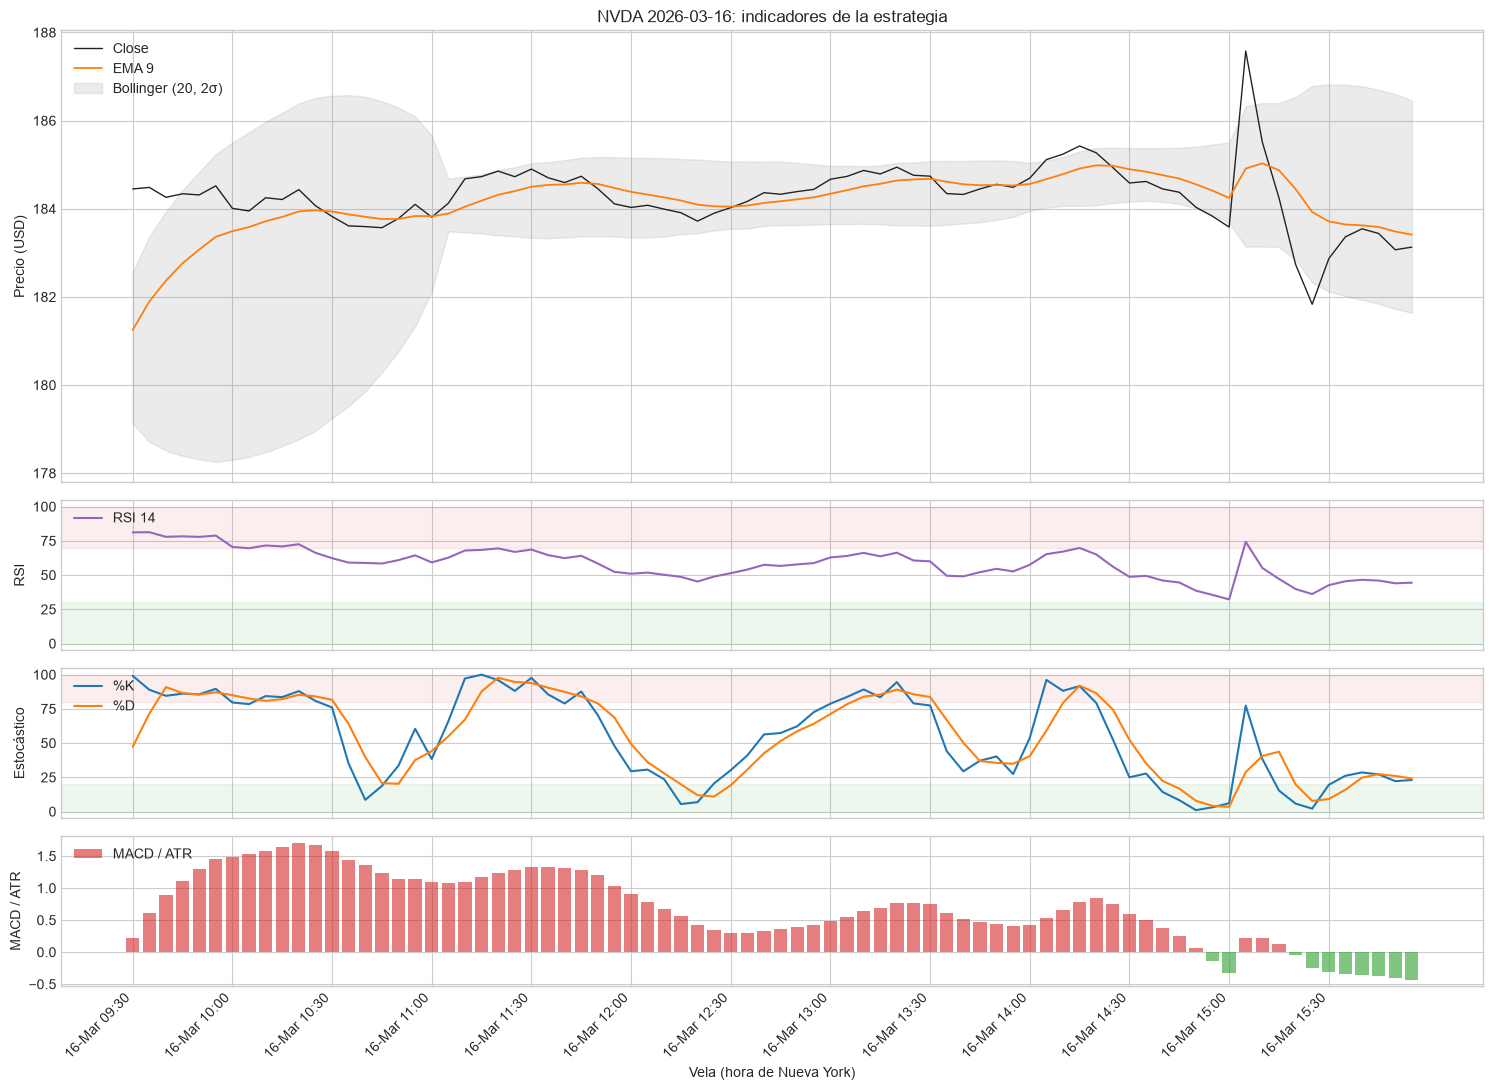

In [7]:
plot_indicadores(indicadores.loc[DIA_EJEMPLO], titulo=f"NVDA {DIA_EJEMPLO}: indicadores de la estrategia")
plt.show()

## 3. Señales: 2 de 3 votos + gatillo EMA 9

In [8]:
senales = generar_senales(train)
senales.loc[senales["senal"] != 0, ["Close", "bb_low", "bb_high", "rsi_14", "stoch_k", "macd_atr", "ema_9",
                                    "volatilidad", "momento", "tendencia", "gatillo_ema", "senal"]].head(10).round(2)

,Close,bb_low,bb_high,rsi_14,stoch_k,macd_atr,ema_9,volatilidad,momento,tendencia,gatillo_ema,senal
Datetime,,,,,,,,,,,,
2026-01-06 10:30:00-05:00,190.85,186.62,193.26,61.04,71.05,1.36,191.04,0,-1,-1,-1,-1
2026-01-07 10:35:00-05:00,189.22,186.17,191.88,50.55,55.20,0.87,190.08,0,-1,-1,-1,-1
2026-01-08 12:45:00-05:00,184.50,183.96,185.37,41.08,41.05,-1.08,184.41,0,1,1,1,1
2026-01-15 10:25:00-05:00,187.60,180.20,191.49,67.58,77.56,2.08,187.70,0,-1,-1,-1,-1
2026-01-15 10:40:00-05:00,187.49,181.81,191.56,62.42,34.31,1.76,187.76,0,-1,-1,-1,-1
2026-01-15 12:15:00-05:00,188.44,186.88,189.24,59.48,56.38,1.18,188.56,0,-1,-1,-1,-1
2026-01-16 09:30:00-05:00,189.28,186.57,189.55,63.78,88.41,-0.46,187.76,0,1,1,1,1
2026-01-20 10:25:00-05:00,180.79,176.17,190.29,28.33,15.18,-2.55,180.77,0,1,1,1,1
2026-01-20 12:55:00-05:00,179.80,179.38,180.37,40.17,55.79,-1.09,179.73,0,1,1,1,1


In [9]:
pd.DataFrame({
    modo: generar_senales(train, modo=modo)["senal"].value_counts().reindex([1, -1], fill_value=0)
    for modo in MODOS
}).rename(index={1: "compras", -1: "ventas"})

,dos_de_tres,estricta,solo_bollinger,solo_momento,solo_macd
senal,,,,,
compras,45,6,61,66,163
ventas,49,3,51,83,175


## 4. Backtest

In [10]:
resultado_train = ejecutar_backtest(senales)
resultado_test = ejecutar_backtest(generar_senales(test))
resultado_train["operaciones"].head(10).round(2)

/var/folders/pk/r0skg4n15qn2ngdpl5bhng2w0000gn/T/ipykernel_11428/3942413920.py:3: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  resultado_train["operaciones"].head(10).round(2)


,direccion,entrada,precio_entrada,acciones,sl,tp,costos,salida,precio_salida,motivo,pnl
0,-1,2026-01-06 10:35:00-05:00,190.86,5239.44,191.96,189.39,2490.38,2026-01-06 10:50:00-05:00,189.39,take-profit,5208.08
1,-1,2026-01-07 10:40:00-05:00,189.23,5312.10,190.43,187.63,2520.97,2026-01-07 10:45:00-05:00,190.43,stop-loss,-8879.08
2,1,2026-01-08 12:50:00-05:00,184.50,5400.16,183.78,185.47,2485.93,2026-01-08 14:20:00-05:00,183.78,stop-loss,-6399.68
3,-1,2026-01-15 10:30:00-05:00,187.60,5276.81,188.74,186.08,2482.32,2026-01-15 11:50:00-05:00,188.74,stop-loss,-8480.87
4,-1,2026-01-15 12:20:00-05:00,188.43,5208.56,189.24,187.34,2458.93,2026-01-15 13:30:00-05:00,189.24,stop-loss,-6702.24
5,1,2026-01-20 10:30:00-05:00,180.78,5391.89,179.61,182.34,2428.99,2026-01-20 11:50:00-05:00,179.61,stop-loss,-8726.28
6,1,2026-01-20 13:00:00-05:00,179.80,5372.75,179.12,180.70,2410.50,2026-01-20 13:35:00-05:00,179.12,stop-loss,-6051.64
7,-1,2026-01-21 15:30:00-05:00,183.78,5223.46,184.63,182.64,2405.50,2026-01-21 15:35:00-05:00,184.63,stop-loss,-6870.17
8,-1,2026-01-27 12:45:00-05:00,189.64,5025.96,190.12,188.98,2378.65,2026-01-27 13:00:00-05:00,188.98,take-profit,899.88
9,1,2026-01-28 12:05:00-05:00,190.81,4999.73,190.06,191.81,2391.23,2026-01-28 13:30:00-05:00,191.81,take-profit,2599.66


In [11]:
resultado_train["operaciones"]["motivo"].value_counts()

motivo
stop-loss        40
take-profit      28
fin de sesión     2
Name: count, dtype: int64

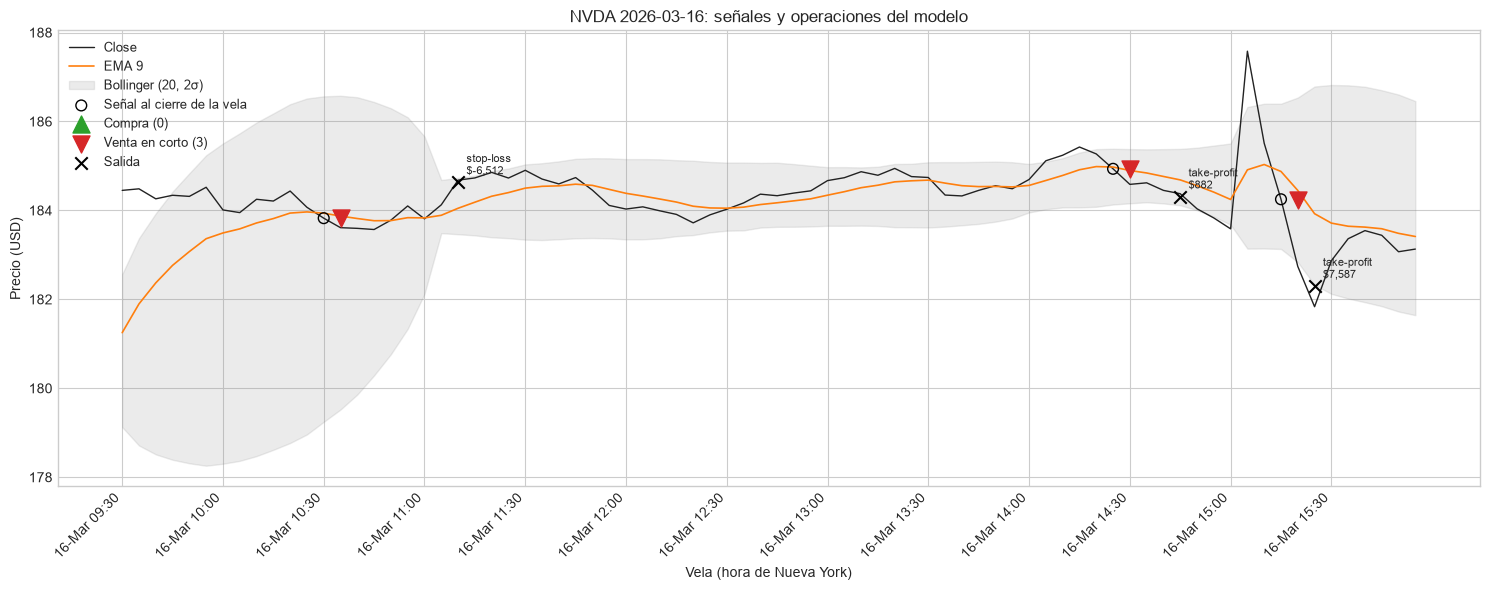

In [12]:
plot_operaciones(senales.loc[DIA_EJEMPLO], resultado_train["operaciones"], titulo=f"NVDA {DIA_EJEMPLO}: señales y operaciones del modelo")
plt.show()

## 5. Métricas

In [13]:
def buy_and_hold(d):
    return d["Close"] / d["Close"].iloc[0] * 1_000_000

pd.DataFrame({
    "train": resumen_metricas(resultado_train["valor"], resultado_train["operaciones"]),
    "buy&hold train": resumen_metricas(buy_and_hold(train), pd.DataFrame()),
    "test": resumen_metricas(resultado_test["valor"], resultado_test["operaciones"]),
    "buy&hold test": resumen_metricas(buy_and_hold(test), pd.DataFrame()),
}).round(4)

,train,buy&hold train,test,buy&hold test
retorno_total,-0.1891,0.0452,-0.1512,0.1624
rendimiento_anualizado,-0.3491,0.0948,-0.4922,0.8625
sharpe,-5.2815,0.4306,-8.0955,1.9233
sortino,-6.5816,0.6226,-9.7732,2.9029
calmar,-1.8063,0.4926,-3.2541,7.6321
max_drawdown,-0.1933,-0.1925,-0.1512,-0.1130
win_rate,0.4000,NaN,0.3509,NaN
operaciones,70.0000,0.0000,57.0000,0.0000


In [14]:
pd.concat({
    nombre: tablas_retornos(r["valor"])["mensual"].mul(100).round(2)
    for nombre, r in (("train", resultado_train), ("test", resultado_test))
}).to_frame("retorno mensual (%)")

retorno mensual (%)
      Datetime                                      
train 2026-01-31 00:00:00-05:00                -4.34
      2026-02-28 00:00:00-05:00                -1.21
      2026-03-31 00:00:00-04:00                -1.96
      2026-04-30 00:00:00-04:00                -4.15
      2026-05-31 00:00:00-04:00                -4.02
      2026-06-30 00:00:00-04:00                -4.86
test  2026-07-31 00:00:00-04:00                -7.14
      2026-08-31 00:00:00-04:00                -4.63
      2026-09-30 00:00:00-04:00                -4.16

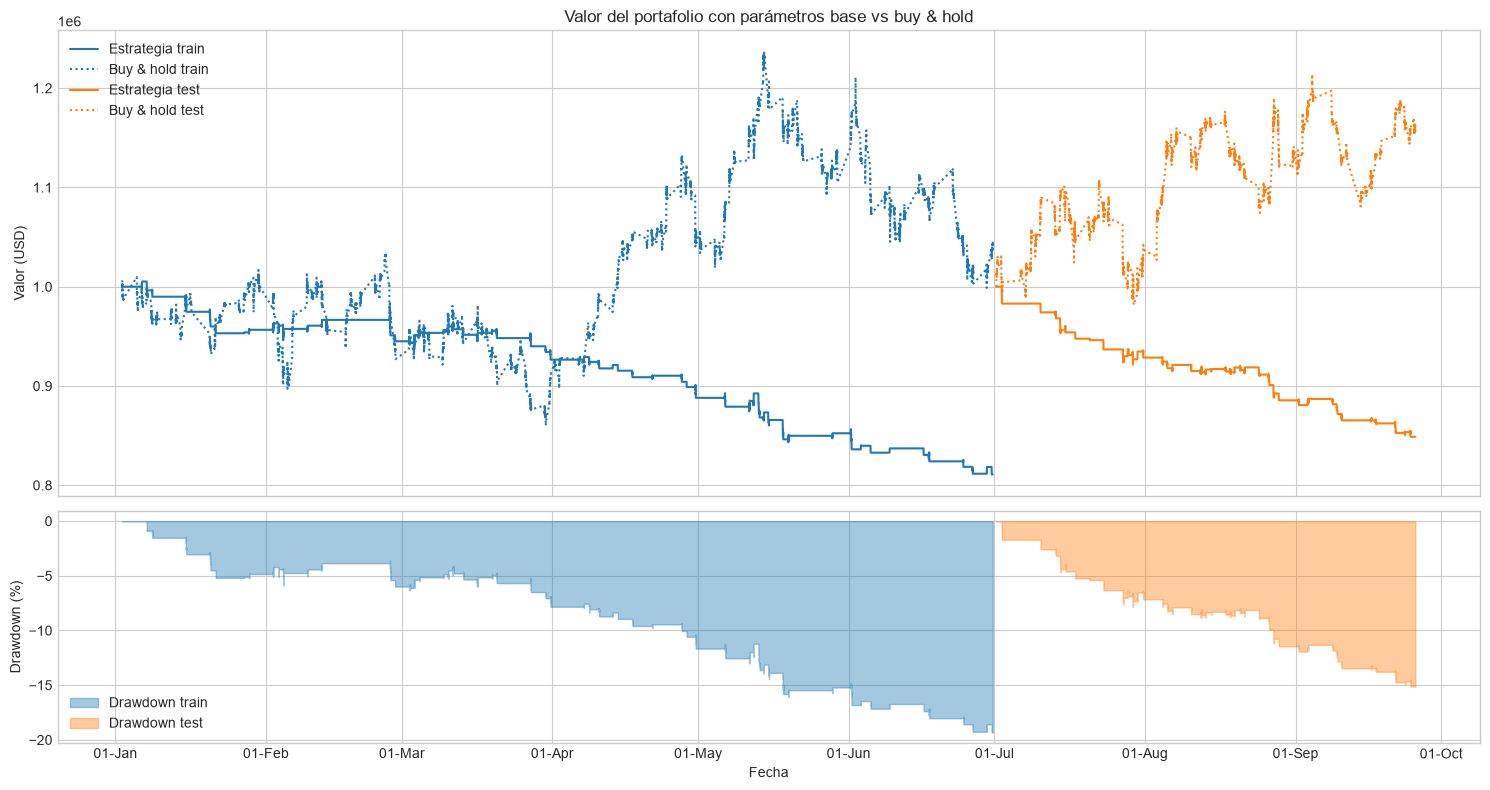

In [15]:
plot_valor_drawdown(
    {"train": (resultado_train["valor"], buy_and_hold(train)), "test": (resultado_test["valor"], buy_and_hold(test))},
    titulo="Valor del portafolio con parámetros base vs buy & hold",
)
plt.show()